# Data centre operation on hydrogen — carbon, one year

Runs the full chain end to end:

```
wind at your site + GB grid  →  PEM electrolyser  →  H2  →  PEM fuel cell  →  data centre
      Renewables.ninja          hydrogen foreground      fuel cell foreground    data centre foreground
```

**Carbon only** (IPCC 2021 GWP100). This deliberately does not run the other
impact categories — see the note at the bottom for why that matters here.

**What it answers:** if the data centre's operation electricity came from
hydrogen, electrolysed from a wind farm at your site with the GB grid topping
up, what would a year cost in CO2e — and how big does the wind farm have to be
before that beats simply plugging the data centre in?

**Why hydrogen decouples from the wind profile.** Notebook 4.1 blends wind
against the *data centre's* demand half-hour by half-hour, because there the
electricity goes straight to the servers. Here the hydrogen is the buffer: the
electrolyser chases the wind, the store absorbs the mismatch, and the data
centre draws flat. So the wind is matched against the **electrolyser's** demand
(~25 MW), not the data centre's (7.3 MW), and the data centre itself is a
constant load.

**The store is not inventoried.** No tank, no compressor, no compression
electricity (~2–3 kWh/kg on top). Those are real and would make the hydrogen
route worse than shown, so treat every hydrogen number here as a floor.

In [1]:
# All settings come from dashboard_config.py — the single master dashboard.
from dashboard_config import *
import dashboard_config as cfg
import lca_helpers as H
import bw2data as bd, bw2calc as bc
import numpy as np, pandas as pd

ei, bio, fg_db, method = H.setup_brightway()

GWP = next(m for m in bd.methods if m[1] == "IPCC 2021" and m[2] == "climate change"
           and "GWP100" in m[3] and "no LT" not in m[1])
print("Carbon method:", GWP)

def carbon(activity, amount=1.0):
    _l = bc.LCA({activity: amount}, GWP); _l.lci(); _l.lcia(); return _l.score

def background(name, location):
    """Exact (name, location) lookup by scanning the database.

    Not a search: ecoinvent's relevance ranking buries some exact names past the
    result cap, and a near-miss here would silently swap the background process.
    """
    hits = [a for a in ei if a.get("name") == name and a.get("location") == location]
    if len(hits) != 1:
        raise ValueError(f"Expected 1 match for {name!r} in {location}, got {len(hits)}")
    return hits[0]

/opt/miniconda3/envs/brightway/lib/python3.11/site-packages/bw2calc/__init__.py:54: UserWarning: 
It seems like you have an ARM architecture, but haven't installed scikit-umfpack:

    https://pypi.org/project/scikit-umfpack/

Installing it could give you much faster calculations.

  warnings.warn(UMFPACK_WARNING)


Current Brightway project: hydrogen-smr
Using ecoinvent database: ecoinvent-3.9.1-apos
Using biosphere database: ecoinvent-3.9.1-biosphere
Using foreground database: hydrogen foreground
Using LCIA method: ('ecoinvent-3.9.1', 'IPCC 2021 no LT', 'climate change no LT', 'global warming potential (GWP100) no LT')
Carbon method: ('ecoinvent-3.9.1', 'IPCC 2021', 'climate change', 'global warming potential (GWP100)')


## The data centre's operation block

The data centre foreground covers a whole 25-year facility. Only its
**operation** exchanges belong in an annual running total — the building shell
and steel are a one-off, not a rate. Those seven exchanges are picked out by
their comments and divided by the 25-year life.

In [2]:
DC   = bd.get_activity((DC_FOREGROUND_DB, "dc_zhang_virginia_baseline_25y"))
FCOP = bd.get_activity((FC_FOREGROUND_DB, "pemfc_op_1kwh_h2"))
H2   = bd.get_activity(tuple(FC_H2_SOURCE))

OPERATION_TAGS = ("IT + cooling/aux", "WUE", "backup gen", "refresh cycles",
                  "UPS", "cooling water treatment", "refrigerant top-up")
op_exc = [e for e in DC.technosphere()
          if any(t in (e.get("comment") or "") for t in OPERATION_TAGS)]
if len(op_exc) != len(OPERATION_TAGS):
    raise ValueError(f"Expected {len(OPERATION_TAGS)} operation exchanges, found {len(op_exc)}. "
                     "Has notebook 2's data centre inventory changed?")
elec_exc = [e for e in op_exc if H.is_any_electricity_exchange(e)]
if len(elec_exc) != 1:
    raise ValueError(f"Expected 1 operation electricity exchange, found {len(elec_exc)}.")

DC_KWH_YEAR   = elec_exc[0].amount / DC_OPERATION_YEARS
DC_OTHER_YEAR = sum(carbon(e.input, e.amount / DC_OPERATION_YEARS)
                    for e in op_exc if e is not elec_exc[0])
DC_KW = DC_KWH_YEAR / 8760

print(f"Operation block ({len(op_exc)} exchanges), per year:")
for e in op_exc:
    print(f"   {e.amount/DC_OPERATION_YEARS:>14,.4g} {e.get('unit',''):<14} {e.input.get('name')}")
print(f"\nElectricity      {DC_KWH_YEAR/1e6:>8.1f} GWh/yr  ({DC_KW/1000:.2f} MW flat)")
print(f"Everything else  {DC_OTHER_YEAR/1e6:>8.2f} kt CO2e/yr  (water, backup diesel, servers, UPS, chemicals)")

_total_exc = len(list(DC.technosphere()))
if _total_exc > 15:
    print(f"\n  NOTE: the live data centre activity has {_total_exc} technosphere exchanges, i.e. it is the")
    print("  full cradle-to-grave version. Notebook 2's current code writes a narrowed 13-flow")
    print("  materials+operation version, so the database predates that change. It does not affect")
    print("  this notebook (the 7 operation exchanges are identical in both), but any whole-facility")
    print("  number you take from that activity is on the wider boundary.")

Operation block (7 exchanges), per year:
          6.4e+07 kilowatt hour  market for electricity, medium voltage
         1.16e+08 kilogram       market group for tap water
         3.44e+05 megajoule      market for diesel, burned in diesel-electric generating set, 10MW
            4,000 unit           market for computer, laptop
              800 kilogram       market for battery, Li-ion, NMC111, rechargeable, prismatic
            5,200 kilogram       market for sodium hypochlorite, without water, in 15% solution state
               18 kilogram       market for refrigerant R134a

Electricity          64.0 GWh/yr  (7.31 MW flat)
Everything else      0.84 kt CO2e/yr  (water, backup diesel, servers, UPS, chemicals)

  NOTE: the live data centre activity has 33 technosphere exchanges, i.e. it is the
  full cradle-to-grave version. Notebook 2's current code writes a narrowed 13-flow
  materials+operation version, so the database predates that change. It does not affect
  this notebook (

## Sizing the chain

Working backwards from the data centre's demand through the fuel cell and the
electrolyser. Both conversion factors are read live from the foreground
activities rather than re-typed, so they can't drift out of sync with notebook 2.

In [3]:
# Split hydrogen into (electricity) + (everything else), so the electricity can
# be re-priced at a wind/grid blend below. Same decomposition the wind notebooks use.
H2_FIXED_PER_KG, H2_KWH_PER_KG, _ = H.run_non_electricity_lca(H2, GWP)

# Split the fuel cell into (hydrogen) + (stack, BoP, maintenance).
FC_H2_PER_KWH_LIVE = sum(e.amount for e in FCOP.technosphere() if e.input.key == H2.key)
FC_FIXED_PER_KWH   = carbon(FCOP) - FC_H2_PER_KWH_LIVE * carbon(H2)

H2_KG_YEAR    = DC_KWH_YEAR * FC_H2_PER_KWH_LIVE
ELEC_KWH_YEAR = H2_KG_YEAR * H2_KWH_PER_KG
ELEC_KW       = ELEC_KWH_YEAR / 8760

wind_bg, grid_bg = background(DC_H2_WIND_QUERY, DC_H2_WIND_LOC), background(DC_H2_GRID_QUERY, DC_H2_GRID_LOC)
CI_WIND, CI_GRID = carbon(wind_bg), carbon(grid_bg)

print(f"fuel cell     {FC_H2_PER_KWH_LIVE:.5f} kg H2/kWh  + {FC_FIXED_PER_KWH*1000:>6.1f} g CO2e/kWh embodied")
print(f"electrolyser  {H2_KWH_PER_KG:.1f} kWh/kg H2   + {H2_FIXED_PER_KG:>6.3f} kg CO2e/kg  (capital, water)")
print()
print(f"→ hydrogen needed        {H2_KG_YEAR/1000:>10,.0f} t/yr")
print(f"→ electrolyser demand    {ELEC_KWH_YEAR/1e6:>10.1f} GWh/yr = {ELEC_KW/1000:.2f} MW flat")
print(f"→ round trip             {ELEC_KWH_YEAR/DC_KWH_YEAR:>10.2f} kWh in per kWh out "
      f"({DC_KWH_YEAR/ELEC_KWH_YEAR*100:.1f}%)")
print()
print(f"Backgrounds: {DC_H2_WIND_LOC} wind {CI_WIND*1000:>6.1f} | {DC_H2_GRID_LOC} grid {CI_GRID*1000:>6.1f} g CO2e/kWh")

fuel cell     0.06316 kg H2/kWh  +   14.0 g CO2e/kWh embodied
electrolyser  54.0 kWh/kg H2   +  0.195 kg CO2e/kg  (capital, water)

→ hydrogen needed             4,043 t/yr
→ electrolyser demand         218.3 GWh/yr = 24.92 MW flat
→ round trip                   3.41 kWh in per kWh out (29.3%)

Backgrounds: GB wind   14.5 | GB grid  311.2 g CO2e/kWh


## Wind at your site

One year of hourly output from Renewables.ninja for the turbine and location in
`dashboard_config.py`. The token is read from this repo's `.env`
(`RENEWABLES_NINJA_TOKEN`), which is gitignored — it is not stored in
`dashboard_config.py`, which is tracked.

In [4]:
REFERENCE_KW = 1000.0   # any value: only the capacity factor is kept

ninja = H.create_ninja_session()
wind_df, ninja_meta, ninja_args = H.fetch_ninja_wind(
    session=ninja, lat=WIND_LAT, lon=WIND_LON,
    date_from=f"{DC_H2_WIND_YEAR}-01-01", date_to=f"{DC_H2_WIND_YEAR}-12-31",
    capacity_kw=REFERENCE_KW, height_m=NINJA_HUB_HEIGHT_M,
    turbine=NINJA_TURBINE, dataset=NINJA_DATASET,
)
cf = wind_df["wind_capacity_factor"].to_numpy()
HOURS_PER_SLICE = 8760 / len(cf)

print(f"Site {WIND_LAT}, {WIND_LON} | {NINJA_TURBINE} @ {NINJA_HUB_HEIGHT_M} m | {NINJA_DATASET} {DC_H2_WIND_YEAR}")
print(f"{len(cf):,} hourly slices | capacity factor {cf.mean():.3f} | "
      f"peak {cf.max():.2f} | hours at zero {int((cf < 0.01).sum()):,}")

Renewables.ninja session created. Source: environment; token length: 40


Status: 200
URL: https://www.renewables.ninja/api/data/wind?lat=51.732&lon=-0.3711&date_from=2025-01-01&date_to=2025-12-31&dataset=merra2&capacity=1000.0&height=80.0&turbine=Vestas+V90+2000&format=json
Site 51.732, -0.3711 | Vestas V90 2000 @ 80.0 m | merra2 2025
8,760 hourly slices | capacity factor 0.349 | peak 0.99 | hours at zero 71


## Sweep the wind farm size

For each installed capacity: the wind farm chases the electrolyser's flat
~25 MW demand hour by hour, the grid tops up whatever the wind doesn't cover,
and anything above 25 MW is spilled (there is nothing else on site to absorb
it, and the electrolyser is sized to the yearly average).

In [5]:
def run_year(installed_kw):
    """One year of the chain at a given wind farm size. Returns a result dict."""
    generated  = cf * installed_kw
    used       = np.minimum(generated, ELEC_KW)
    wind_kwh   = used.sum() * HOURS_PER_SLICE
    spilled    = generated.sum() * HOURS_PER_SLICE - wind_kwh
    grid_kwh   = ELEC_KWH_YEAR - wind_kwh

    h2_carbon  = wind_kwh * CI_WIND + grid_kwh * CI_GRID + H2_FIXED_PER_KG * H2_KG_YEAR
    total      = h2_carbon + FC_FIXED_PER_KWH * DC_KWH_YEAR + DC_OTHER_YEAR
    return {
        "wind_mw": installed_kw / 1000,
        "wind_share": wind_kwh / ELEC_KWH_YEAR,
        "wind_gwh": wind_kwh / 1e6,
        "grid_gwh": grid_kwh / 1e6,
        "spilled_gwh": spilled / 1e6,
        "kt_co2e_yr": total / 1e6,
        "g_co2e_per_kwh": total / DC_KWH_YEAR * 1000,
    }

sweep = pd.DataFrame([run_year(mw * 1000) for mw in DC_H2_WIND_CAPACITIES_MW])

# Reference cases: the data centre plugged straight in, no hydrogen anywhere.
serc_bg = background("market for electricity, medium voltage", "US-SERC")
REFERENCE = {
    "US-SERC grid (paper baseline)": carbon(serc_bg) * DC_KWH_YEAR + DC_OTHER_YEAR,
    f"{DC_H2_GRID_LOC} grid, direct":  CI_GRID * DC_KWH_YEAR + DC_OTHER_YEAR,
    f"{DC_H2_WIND_LOC} wind, direct":  CI_WIND * DC_KWH_YEAR + DC_OTHER_YEAR,
}
BASELINE = REFERENCE["US-SERC grid (paper baseline)"]
sweep["vs_baseline"] = sweep["kt_co2e_yr"] * 1e6 / BASELINE

print("=" * 96)
print(f"DATA CENTRE OPERATION ON HYDROGEN — {DC_KWH_YEAR/1e6:.1f} GWh delivered, one year, carbon only")
print("=" * 96)
print(f"{'wind farm':>10}{'wind share':>12}{'grid top-up':>13}{'spilled':>11}"
      f"{'kt CO2e/yr':>13}{'g CO2e/kWh':>13}{'vs baseline':>13}")
for _, r in sweep.iterrows():
    print(f"{r.wind_mw:>7.0f} MW{r.wind_share*100:>11.1f}%{r.grid_gwh:>10.1f} GWh"
          f"{r.spilled_gwh:>8.1f} GWh{r.kt_co2e_yr:>13.1f}{r.g_co2e_per_kwh:>13.0f}{r.vs_baseline:>12.2f}x")
print("-" * 96)
for label, value in REFERENCE.items():
    print(f"{label:>36}{'':>23}{value/1e6:>13.1f}{value/DC_KWH_YEAR*1000:>13.0f}{value/BASELINE:>12.2f}x")

_beat = sweep[sweep.vs_baseline < 1.0]
print()
if len(_beat):
    print(f"Hydrogen first beats the baseline at {_beat.iloc[0].wind_mw:.0f} MW of wind "
          f"({_beat.iloc[0].wind_share*100:.0f}% wind share).")
else:
    print("Hydrogen does not beat the baseline at any wind size in the sweep.")
print(f"Direct wind, with no hydrogen anywhere, is {REFERENCE[f'{DC_H2_WIND_LOC} wind, direct']/1e6:.1f} kt/yr — "
      f"{sweep.kt_co2e_yr.min()/(REFERENCE[f'{DC_H2_WIND_LOC} wind, direct']/1e6):.0f}x lower than the best hydrogen case.")

DATA CENTRE OPERATION ON HYDROGEN — 64.0 GWh delivered, one year, carbon only
 wind farm  wind share  grid top-up    spilled   kt CO2e/yr   g CO2e/kWh  vs baseline
      0 MW        0.0%     218.3 GWh     0.0 GWh         70.5         1101        2.10x
     10 MW       14.0%     187.7 GWh     0.0 GWh         61.4          959        1.83x
     25 MW       35.0%     141.8 GWh     0.0 GWh         47.8          746        1.43x
     50 MW       61.5%      84.2 GWh    18.8 GWh         30.7          479        0.92x
     75 MW       75.1%      54.3 GWh    65.3 GWh         21.8          340        0.65x
    100 MW       82.0%      39.2 GWh   126.7 GWh         17.3          271        0.52x
    150 MW       88.4%      25.3 GWh   265.7 GWh         13.2          206        0.39x
    200 MW       91.4%      18.7 GWh   412.0 GWh         11.2          175        0.34x
------------------------------------------------------------------------------------------------
       US-SERC grid (paper baseline

## Plot and export

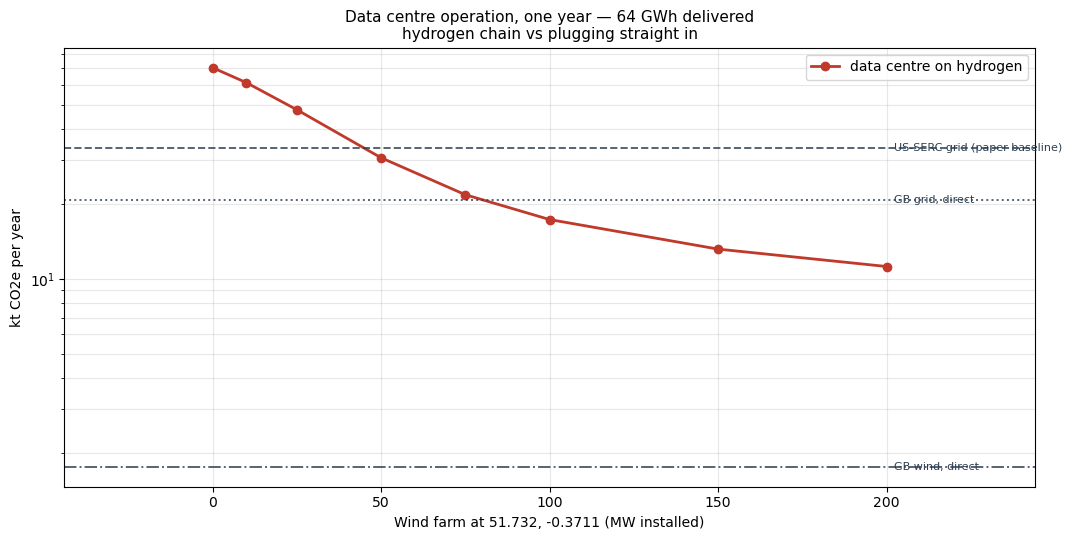

Saved to /Users/louis/lca-ai-project/ukelectrolyserlca/datacentre_hydrogen_outputs


In [6]:
import matplotlib.pyplot as plt
from pathlib import Path

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(sweep.wind_mw, sweep.kt_co2e_yr, "o-", lw=2, color="#c0392b",
        label="data centre on hydrogen")
for (label, value), style in zip(REFERENCE.items(), ["--", ":", "-."]):
    ax.axhline(value / 1e6, ls=style, lw=1.4, color="#2c3e50", alpha=0.8)
    ax.text(sweep.wind_mw.max(), value / 1e6, f"  {label}", va="center", fontsize=8, color="#2c3e50")
ax.set_xlabel(f"Wind farm at {WIND_LAT}, {WIND_LON} (MW installed)")
ax.set_ylabel("kt CO2e per year")
ax.set_title(f"Data centre operation, one year — {DC_KWH_YEAR/1e6:.0f} GWh delivered\n"
             f"hydrogen chain vs plugging straight in", fontsize=11)
ax.set_yscale("log"); ax.grid(alpha=0.3, which="both"); ax.legend(loc="upper right")
ax.margins(x=0.22)
plt.tight_layout(); plt.show()

out = Path("datacentre_hydrogen_outputs"); out.mkdir(exist_ok=True)
sweep.to_csv(out / f"dc_h2_wind_sweep_{DC_H2_WIND_YEAR}.csv", index=False)
pd.Series({k: v / 1e6 for k, v in REFERENCE.items()}, name="kt_co2e_yr").to_csv(
    out / f"dc_h2_reference_cases_{DC_H2_WIND_YEAR}.csv")
print("Saved to", out.resolve())

## Reading this

**The round trip is the whole story.** 3.4 kWh in per kWh out means the wind
farm has to be roughly three and a half times bigger than the data centre's
demand before hydrogen breaks even against just buying that electricity. Every
carbon number here is dominated by the electrolyser's electricity — the fuel
cell stack, its balance of plant and the electrolyser's own capital together are
around 1% of the total.

**Hydrogen never beats direct supply.** At every wind size in the sweep,
sending the wind straight to the servers is far cleaner than routing it through
hydrogen. That is arithmetic, not modelling: you cannot lose 70% of the energy
and come out ahead on the same electricity.

So the case for this chain is never "it is lower carbon than plugging in". It is
one of:

- **storage** — the wind is there at 3am and the servers are not, and the
  alternative for that particular electricity is curtailment, not use. Notebook
  4's `surplus_wind_kw` column is the right input for that framing, and the
  spilled column above shows how much there is to work with;
- **backup** — replacing diesel gensets, where the comparison is against diesel
  and runtime is hours per year, not 8,760;
- **grid independence**, which is not a carbon argument at all.

**Carbon only.** You asked for carbon and this notebook gives you carbon, but
the earlier full-impact run flagged something a carbon-only view hides: on
ecotoxicity, human carcinogenic toxicity and mineral resource scarcity, the
hydrogen route is *worse than the US-SERC baseline* even when it is running on
wind — roughly 2x on toxicity and 3x on metals, because you are building three
and a half times the wind turbines plus an electrolyser plus stacks. If this
work is heading for publication, that burden shift is likely to be the first
thing a reviewer asks about.

**Not counted, and all of it pushes the same way:** hydrogen storage and
compression, the fuel cell's balance-of-plant beyond ecoinvent's PEMFC system,
and the wind farm's own curtailment economics. Every number above is a floor.